In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBRegressor

## Đọc dữ liệu

In [2]:
df = pd.read_csv(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\data\live\sales_dashboard.csv")
df.head()

,order_id,order_purchase_timestamp,price,freight_value,payment_value,order_status,seller_id,customer_unique_id,customer_city,customer_state,product_category_name,Category_VN,product_id
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,8.72,38.71,delivered,3504c0cb71d7fa48d967e0e4c94d59d9,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,utilidades_domesticas,Đồ gia dụng,87285b34884572647811a353c7ac498a
1,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,27.20,72.20,delivered,66922902710d126a0e7d26b0e3805106,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,pet_shop,Thú cưng,d0b61bfb1de832b15ba9d266ca96e5b0
2,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,8.72,28.62,delivered,2c9e548be18521d1c43cde1c582c6de8,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,papelaria,Văn phòng phẩm,65266b2da20d04dbe00c5c2d3bb7859e
3,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,147.90,27.36,175.26,delivered,8581055ce74af1daba164fdbd55a40de,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,automotivo,Phụ tùng ô tô,060cb19345d90064d1015407193c233d
4,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,59.99,15.17,75.16,delivered,16090f2ca825584b5a147ab24aa30c86,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,automotivo,Phụ tùng ô tô,4520766ec412348b8d4caa5e8a18c464


## Kiểm tra dữ liệu

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100853 entries, 0 to 100852
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  100853 non-null  object 
 1   order_purchase_timestamp  100853 non-null  object 
 2   price                     100853 non-null  float64
 3   freight_value             100853 non-null  float64
 4   payment_value             100853 non-null  float64
 5   order_status              100853 non-null  object 
 6   seller_id                 100853 non-null  object 
 7   customer_unique_id        100853 non-null  object 
 8   customer_city             100853 non-null  object 
 9   customer_state            100853 non-null  object 
 10  product_category_name     100853 non-null  object 
 11  Category_VN               100853 non-null  object 
 12  product_id                100853 non-null  object 
dtypes: float64(3), object(10)
memory usage: 10.0

,price,freight_value,payment_value
count,100853.000000,100853.000000,100853.000000
mean,120.008066,19.853701,179.894830
std,180.412420,15.469460,273.820426
min,0.850000,0.000000,10.070000
25%,39.900000,13.080000,65.700000
50%,74.900000,16.190000,114.450000
75%,134.640000,21.020000,195.120000
max,6735.000000,409.680000,13664.080000


## Kiểm tra và xử lý dữ liệu thiếu

In [4]:
df.isnull().sum()
df = df.dropna()

## Chuyển cột thời gian sang datetime

In [5]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

## Feature Engineering từ thời gian

In [6]:
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['day'] = df['order_purchase_timestamp'].dt.day
df['hour'] = df['order_purchase_timestamp'].dt.hour

## Xóa cột timestamp

In [7]:
df = df.drop(columns=['order_purchase_timestamp'])

## Encode dữ liệu categorical

In [8]:
le = LabelEncoder()

categorical_cols = [
    'order_status',
    'seller_id',
    'customer_unique_id',
    'customer_city',
    'customer_state',
    'product_category_name',
    'Category_VN',
    'product_id'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

## Chọn feature và target

In [9]:
X = df.drop(columns=['payment_value','order_id'])
y = df['payment_value']

## Chia dữ liệu train và test

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Khởi tạo mô hình XGBoost

In [11]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

## Huấn luyện mô hình

In [12]:
model.fit(X_train, y_train)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.05, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=200, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0, reg_lambda=1, ...)

## Dự đoán trên tập test

In [13]:
y_pred = model.predict(X_test)

## So sánh kết quả dự đoán

In [14]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head()

,Actual,Predicted
42699,163.58,173.789948
12724,82.65,85.562294
17567,78.42,56.126980
1384,138.21,104.025673
81881,213.45,107.848595


## Đánh giá mô hình

### MAE 
#### Đo sai số tuyệt đối trung bình giữa giá trị dự đoán và thực tế.

In [15]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 51.91919432304344


### MSE
#### Đo sai số bình phương trung bình của mô hình.

In [16]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 10918.205469644643


### RMSE
#### Đánh giá sai số dự đoán ở cùng đơn vị với biến mục tiêu.

In [17]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 104.49021710018907


## Trực quan hóa kết quả dự đoán

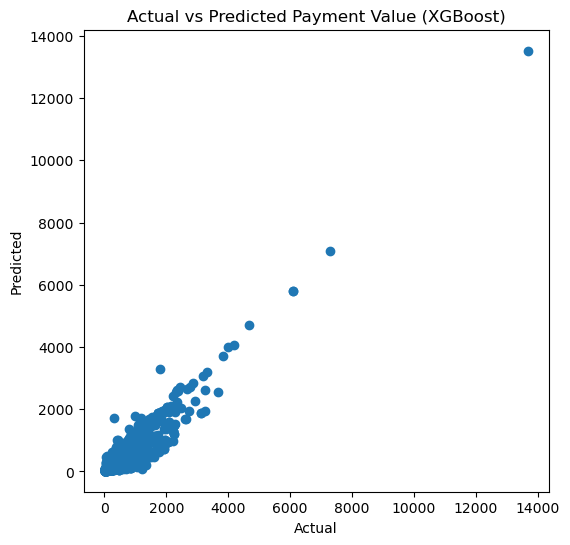

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Payment Value (XGBoost)")
plt.show()

### Lưu model vào file bkl

In [19]:
import pickle


with open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models/xgboost_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [20]:
import pickle

pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models/xgboost_model.pkl","rb"))

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.05, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=200, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0, reg_lambda=1, ...)